<a href="https://colab.research.google.com/github/isg-data/insurance_eda/blob/main/EDA_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ============================================
# EDA: Medical Cost Personal Dataset
# ============================================

# Pakete laden (in Colab ggf. vorher installieren)
# install.packages(c("tidyverse"))
library(tidyverse)

In [8]:
# ---------------------------------------------
# 1. Daten laden
# ---------------------------------------------
# Passe den Pfad an dein Repo an, z.B. "data/insurance.csv"
df <- read.csv("sample_data/insurance.csv", stringsAsFactors = FALSE)

# Erster Überblick
str(df)
head(df)
summary(df)

# Fehlende Werte prüfen
colSums(is.na(df))

# Datentypen anpassen (kategoriale Variablen als Faktoren)
df <- df %>%
  mutate(
    sex = as.factor(sex),
    smoker = as.factor(smoker),
    region = as.factor(region)
  )

'data.frame':	1338 obs. of  7 variables:
 $ age     : int  19 18 28 33 32 31 46 37 37 60 ...
 $ sex     : chr  "female" "male" "male" "male" ...
 $ bmi     : num  27.9 33.8 33 22.7 28.9 ...
 $ children: int  0 1 3 0 0 0 1 3 2 0 ...
 $ smoker  : chr  "yes" "no" "no" "no" ...
 $ region  : chr  "southwest" "southeast" "southeast" "northwest" ...
 $ charges : num  16885 1726 4449 21984 3867 ...


,age,sex,bmi,children,smoker,region,charges
,<int>,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>
1,19,female,27.900,0,yes,southwest,16884.924
2,18,male,33.770,1,no,southeast,1725.552
3,28,male,33.000,3,no,southeast,4449.462
4,33,male,22.705,0,no,northwest,21984.471
5,32,male,28.880,0,no,northwest,3866.855
6,31,female,25.740,0,no,southeast,3756.622


      age               sex            bmi           children    
 Min.   :18.00   Length   :1338   Min.   :15.96   Min.   :0.000  
 1st Qu.:27.00   N.unique :   2   1st Qu.:26.30   1st Qu.:0.000  
 Median :39.00   N.blank  :   0   Median :30.40   Median :1.000  
 Mean   :39.21   Min.nchar:   4   Mean   :30.66   Mean   :1.095  
 3rd Qu.:51.00   Max.nchar:   6   3rd Qu.:34.69   3rd Qu.:2.000  
 Max.   :64.00                    Max.   :53.13   Max.   :5.000  
       smoker           region        charges     
 Length   :1338   Length   :1338   Min.   : 1122  
 N.unique :   2   N.unique :   4   1st Qu.: 4740  
 N.blank  :   0   N.blank  :   0   Median : 9382  
 Min.nchar:   2   Min.nchar:   9   Mean   :13270  
 Max.nchar:   3   Max.nchar:   9   3rd Qu.:16640  
                                   Max.   :63770  

age      sex      bmi children   smoker   region  charges 
       0        0        0        0        0        0        0

# A tibble: 2 × 4
  smoker mean_charges median_charges     n
  <fct>         <dbl>          <dbl> <int>
1 no            8434.          7345.  1064
2 yes          32050.         34456.   274


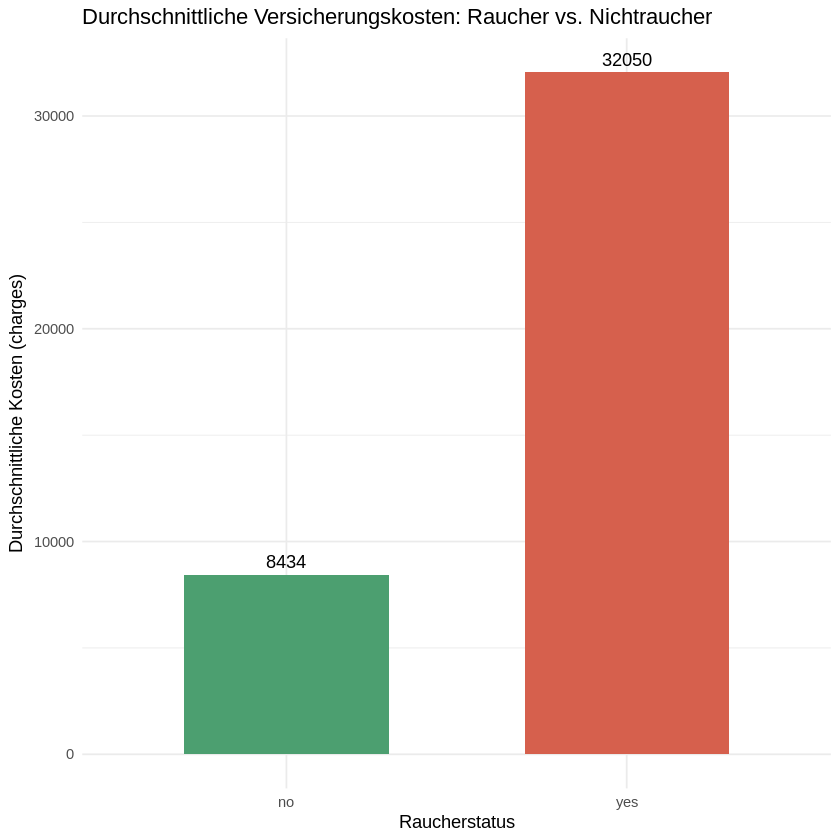

In [9]:
# ---------------------------------------------
# 2. Balkendiagramm: smoker vs. charges
#    (Durchschnittliche Kosten je Rauchstatus)
# ---------------------------------------------
smoker_summary <- df %>%
  group_by(smoker) %>%
  summarise(
    mean_charges = mean(charges),
    median_charges = median(charges),
    n = n()
  )

print(smoker_summary)

ggplot(smoker_summary, aes(x = smoker, y = mean_charges, fill = smoker)) +
  geom_col(width = 0.6) +
  geom_text(aes(label = round(mean_charges, 0)), vjust = -0.5) +
  labs(
    title = "Durchschnittliche Versicherungskosten: Raucher vs. Nichtraucher",
    x = "Raucherstatus",
    y = "Durchschnittliche Kosten (charges)"
  ) +
  scale_fill_manual(values = c("no" = "#4C9F70", "yes" = "#D6604D")) +
  theme_minimal() +
  theme(legend.position = "none")


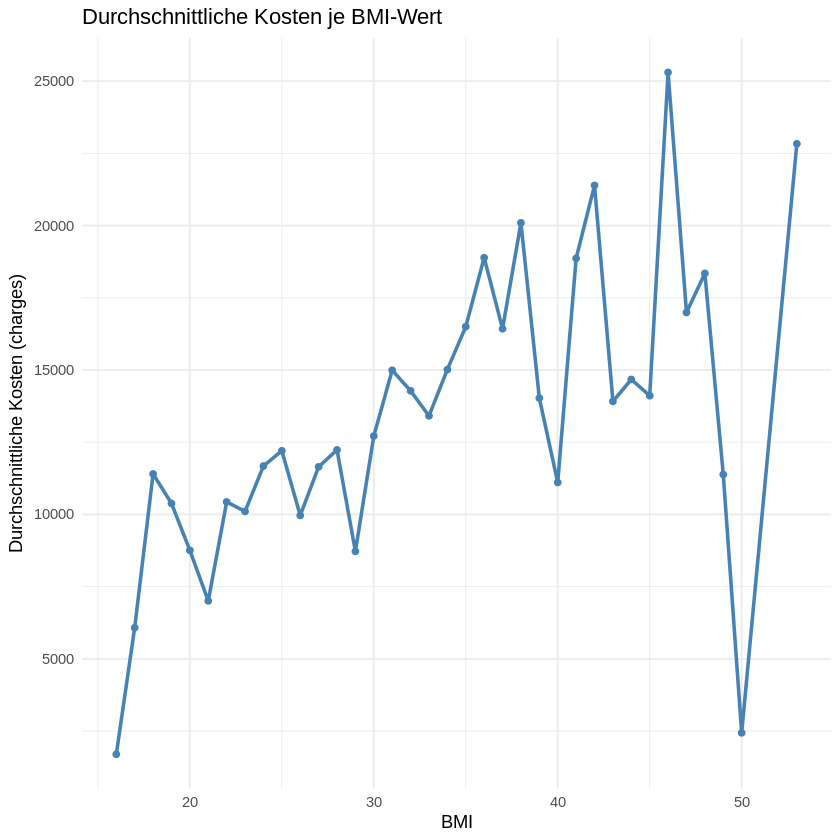

In [11]:

# ---------------------------------------------
# 3. Liniendiagramm: bmi vs. charges
# ---------------------------------------------

# Variante A: "echte" Linie über nach BMI gruppierte Mittelwerte
# (bessere Wahl, falls explizit ein klassisches Liniendiagramm gefordert ist)
bmi_binned <- df %>%
  mutate(bmi_bin = round(bmi)) %>%
  group_by(bmi_bin) %>%
  summarise(mean_charges = mean(charges))

ggplot(bmi_binned, aes(x = bmi_bin, y = mean_charges)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_point(color = "steelblue") +
  labs(
    title = "Durchschnittliche Kosten je BMI-Wert",
    x = "BMI",
    y = "Durchschnittliche Kosten"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


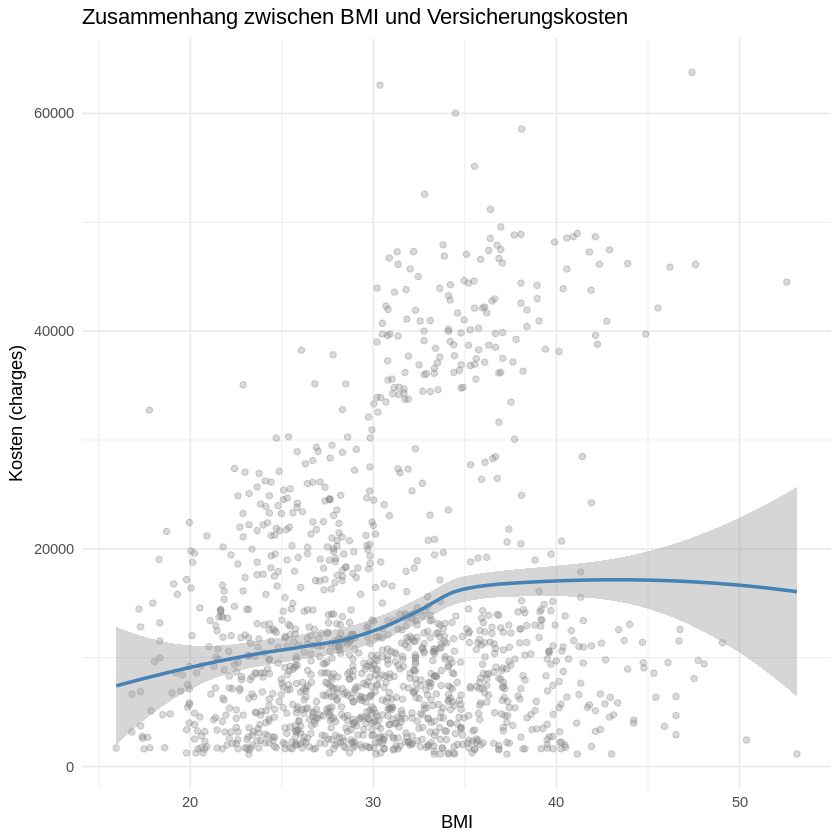

In [12]:
# Variante B: geglättete Trendlinie
ggplot(df, aes(x = bmi, y = charges)) +
  geom_point(alpha = 0.3, color = "grey50") +
  geom_smooth(method = "loess", color = "steelblue", se = TRUE) +
  labs(
    title = "Zusammenhang zwischen BMI und Versicherungskosten",
    x = "BMI",
    y = "Kosten (charges)"
  ) +
  theme_minimal()